# Random forest model

This notebook compares a class-weighted random forest with the logistic
regression baseline.

The objective is to improve failure detection while reducing the number
of false maintenance alarms.

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print(f"Project source: {SRC_PATH}")

Project source: /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/src


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import ConfusionMatrixDisplay

from predictive_maintenance.data import load_data
from predictive_maintenance.evaluate import calculate_metrics
from predictive_maintenance.features import create_features
from predictive_maintenance.train import (
    create_logistic_model,
    create_random_forest_model,
    split_data,
)

In [6]:
df = load_data()
X, y = create_features(df)

X_train, X_test, y_train, y_test = split_data(X, y)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Loading local dataset from /Users/alexanderkorolev/Desktop/predictive-maintenance-ai4i/data/raw/ai4i2020.csv
Training observations: 8000
Test observations: 2000


In [7]:
logistic_model = create_logistic_model(X_train)
logistic_model.fit(X_train, y_train)

random_forest_model = create_random_forest_model(X_train)
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Type','Air temperature','Process temperature','Rotational speed', 'Torque','Tool wear']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [8]:
logistic_metrics = calculate_metrics(
    logistic_model,
    X_test,
    y_test,
)

random_forest_metrics = calculate_metrics(
    random_forest_model,
    X_test,
    y_test,
)

results = pd.DataFrame(
    [
        {
            "model": "Logistic regression",
            **logistic_metrics,
        },
        {
            "model": "Random forest",
            **random_forest_metrics,
        },
    ]
)

results.set_index("model").round(3)

,accuracy,precision,recall,f1_score,pr_auc
model,,,,,
Logistic regression,0.824,0.142,0.824,0.242,0.382
Random forest,0.982,0.820,0.603,0.695,0.760


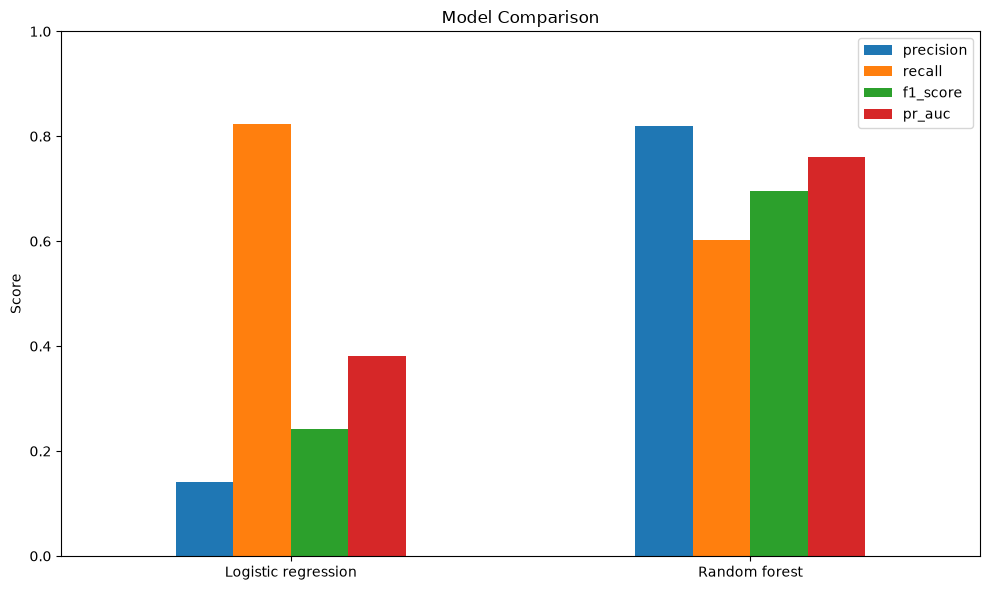

In [9]:
results.set_index("model")[
    ["precision", "recall", "f1_score", "pr_auc"]
].plot(
    kind="bar",
    figsize=(10, 6),
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

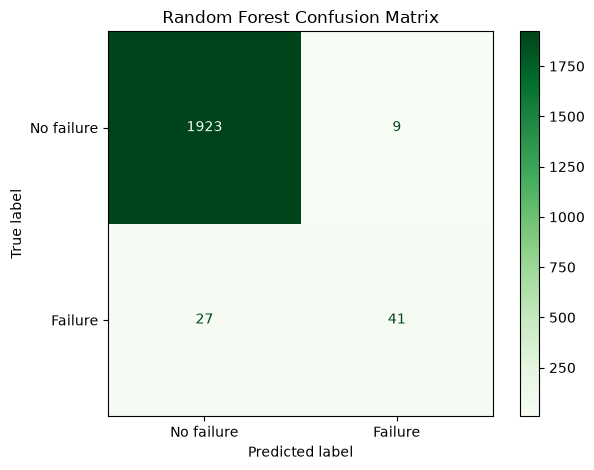

In [10]:
ConfusionMatrixDisplay.from_estimator(
    random_forest_model,
    X_test,
    y_test,
    display_labels=["No failure", "Failure"],
    cmap="Greens",
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
preprocessor = random_forest_model.named_steps["preprocessor"]
classifier = random_forest_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()
feature_importances = classifier.feature_importances_

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": feature_importances,
        }
    )
    .sort_values("importance", ascending=False)
)

importance_df

,feature,importance
3,numerical__Torque,0.306660
2,numerical__Rotational speed,0.300557
4,numerical__Tool wear,0.198303
0,numerical__Air temperature,0.102134
1,numerical__Process temperature,0.073074
6,categorical__Type_L,0.009411
7,categorical__Type_M,0.006474
5,categorical__Type_H,0.003389


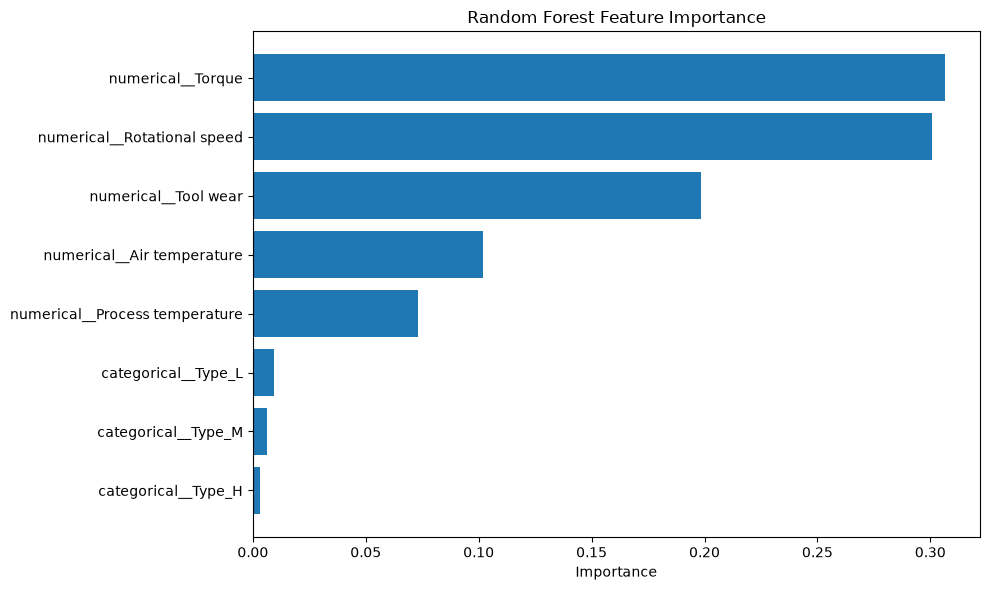

In [12]:
plot_data = importance_df.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_data["feature"], plot_data["importance"])

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Interpretation

The random forest substantially outperforms the logistic regression in terms
of precision, F1-score, and PR-AUC.

It correctly detects 41 of 68 machine failures and produces only 9 false
alarms. Compared with the logistic regression, the number of false alarms is
therefore reduced from 339 to 9. However, the recall decreases from
approximately 82% to 60%, meaning that 27 failures remain undetected.

The feature importance analysis indicates that torque, rotational speed, and
tool wear contribute most strongly to the random forest predictions.
The product type has comparatively little influence.

Overall, the random forest provides much more reliable maintenance alarms,
but its decision threshold should be optimized to detect more failures while
maintaining an acceptable false-alarm rate.